# Python Seminar No.6

`MNICT_train.csv.zip` を使って、手書き数字画像のデータを可視化・クラスタリングします。

このノートブックでは、1枚の画像を `pixel_0` から `pixel_783` までの784個の数値として扱います。28 x 28 = 784 なので、1行が1枚の28x28画像を表します。画像をそのまま眺めるだけでは全体の構造が分かりにくいため、PCAやUMAPで2次元に圧縮し、さらにクラスタリングで似ている画像同士をグループに分けます。

今回は以下を行います。

- PCAによる2次元可視化
- PCAの寄与率と累積寄与率の確認
- PC1からPC10までの10x10プロット
- PCAローディングの可視化
- UMAPによる2次元可視化
- 階層的クラスタリングとデンドログラム
- k-meansによる非階層的クラスタリング
- クラスタリング結果をPCAの図に併記
- 教師あり学習と教師なし学習の違いの整理

**このノートブックで見たいこと**

点の位置や色分けを通して、似ている手書き数字画像が近くに集まるか、いくつかのまとまりに分かれるかを確認します。今回のデータには正解ラベル列が入っていないため、「この画像は数字の何か」を直接評価するのではなく、画像の特徴だけから構造を探す教師なし学習として扱います。


## 1. ライブラリの読み込み

データの読み込み、前処理、可視化、次元削減、クラスタリングに使うライブラリを読み込みます。

`pandas` はCSVを表として扱うため、`numpy` は数値計算のため、`matplotlib` はグラフ描画のために使います。`scikit-learn` からは標準化、PCA、k-means、階層的クラスタリング、t-SNE、評価指標を読み込みます。デンドログラムの描画には `scipy` の階層クラスタリング機能を使います。


In [ ]:
# ファイルの場所を扱うためのライブラリを読み込みます。
from pathlib import Path

# zipファイルの中にあるCSVを読むためのライブラリを読み込みます。
import zipfile

# 数値計算をするためのライブラリを読み込みます。
import numpy as np

# 表形式のデータを扱うためのライブラリを読み込みます。
import pandas as pd

# グラフを描くためのライブラリを読み込みます。
import matplotlib.pyplot as plt

# 特徴量の大きさをそろえる道具を読み込みます。
from sklearn.preprocessing import StandardScaler

# PCAを読み込みます。
from sklearn.decomposition import PCA

# k-meansクラスタリングを読み込みます。
from sklearn.cluster import KMeans, AgglomerativeClustering

# t-SNEを読み込みます。UMAPが使えない場合の代わりとして使います。
from sklearn.manifold import TSNE

# 階層的クラスタリングのデンドログラムを描く道具を読み込みます。
from scipy.cluster.hierarchy import linkage, dendrogram

# クラスタリング結果を評価する指標を読み込みます。
from sklearn.metrics import silhouette_score

: 

## 2. CSVファイルの読み込み

`MNICT_train.csv.zip` の中には、CSV本体のほかにMacのメタデータファイルも入っています。

そのため、zipの中から `MNICT_train.csv` を指定して読み込みます。

このデータは行数が多いため、授業中に動かしやすいように最初は `n_rows = 10000` としています。全データで実行したい場合は `n_rows = None` に変更してください。

読み込んだ直後に `df.head()` を表示することで、列名、値の並び、先頭列がどのようなIDになっているかを確認します。大きなデータを扱うときは、最初に少ない行数で処理の流れを確認してから、必要に応じて行数を増やすと実行時間を管理しやすくなります。


In [2]:
# 読み込むzipファイルの場所を指定します。
zip_path = Path("MNICT_train.csv.zip")

# 授業中に動かしやすいように、読み込む行数を指定します。
# 全データを使いたい場合は、n_rows = None に変更してください。
n_rows = 10000

# zipファイルの中にあるCSV本体を指定して読み込みます。
with zipfile.ZipFile(zip_path) as z:
    with z.open("MNICT_train.csv") as f:
        df = pd.read_csv(f, nrows=n_rows)

# データの先頭5行を表示して、内容を確認します。
df.head()

,Unnamed: 0,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. データの基本情報を確認する

このCSVは、最初の列が行番号、残りの `pixel_0` から `pixel_783` が画像のピクセル値です。

28 x 28 = 784 なので、1行が1枚の28x28画像を表しています。

ここで確認する内容は、行数と列数、列名、欠損値、先頭列の値です。欠損値があると標準化やPCAでエラーや不自然な結果につながるため、解析前に確認します。先頭列は画像そのものの明るさではなくIDとして扱い、PCAやクラスタリングの入力には使いません。


In [3]:
# データの行数と列数を確認します。
print("データの形:", df.shape)

# 列名を確認します。
print("最初の10列:")
print(df.columns[:10].tolist())

# 欠損値の数を確認します。
print("\n欠損値の数:")
print(df.isna().sum().sum())

# 先頭列が行番号かどうかを確認します。
print("\n先頭列の最初の10個:")
print(df.iloc[:10, 0].tolist())

データの形: (10000, 785)
最初の10列:
['Unnamed: 0', 'pixel_0', 'pixel_1', 'pixel_2', 'pixel_3', 'pixel_4', 'pixel_5', 'pixel_6', 'pixel_7', 'pixel_8']

欠損値の数:
0

先頭列の最初の10個:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## 4. 画像データだけを取り出す

クラスタリングやPCAに使う説明変数 `X` として、ピクセル列だけを取り出します。

ここでいう**説明変数**とは、データを説明するためにモデルへ入力する列のことです。今回の場合、各ピクセルの明るさが説明変数です。`pixel_0` から `pixel_783` までの784列を使うので、1枚の画像は784次元のデータとして表されます。

今回のファイルには正解ラベル列が入っていないため、正解ラベルで色分けする代わりに、後でクラスタリング結果で色分けします。先頭列は画像IDとして保存しておき、表示タイトルなどに使います。


In [4]:
# pixel_で始まる列だけを取り出します。
pixel_columns = [col for col in df.columns if col.startswith("pixel_")]

# ピクセル列を説明変数Xにします。
X = df[pixel_columns]

# 画像の番号として、先頭列を保存しておきます。
image_id = df.iloc[:, 0]

# 説明変数の形を確認します。
print("説明変数の形:", X.shape)

# ピクセル値の最小値と最大値を確認します。
print("ピクセル値の最小値:", X.min().min())
print("ピクセル値の最大値:", X.max().max())

説明変数の形: (10000, 784)
ピクセル値の最小値: 0
ピクセル値の最大値: 255


## 5. 手書き数字画像を表示する

ピクセル値を28x28に戻して、実際にどのような画像か確認します。

CSV上では1枚の画像が横一列の784個の数値として保存されています。`reshape(28, 28)` によって、横一列のデータを画像の形に戻します。`cmap="gray"` は白黒画像として表示する指定です。

この確認により、ピクセル列の取り出しが正しくできているか、画像が想定通りの向きで表示されているかを目で確認できます。


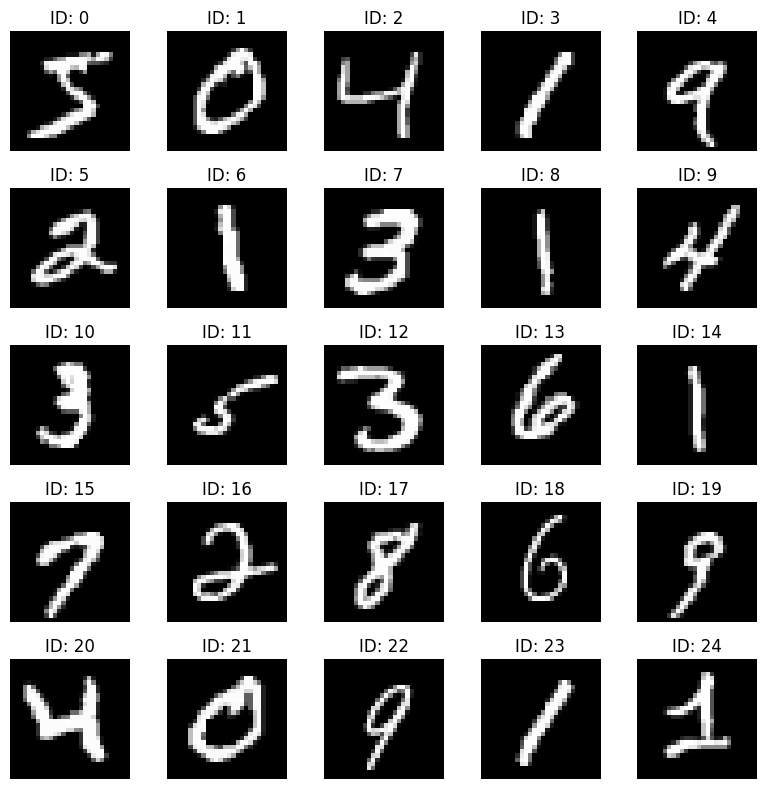

In [5]:
# 表示する画像の枚数を指定します。
n_images = 25

# 5行5列で画像を表示します。
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
axes = axes.ravel()

for i, ax in enumerate(axes):
    image = X.iloc[i].to_numpy().reshape(28, 28)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"ID: {image_id.iloc[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6. 標準化する

PCAやクラスタリングでは、特徴量の大きさが結果に影響します。

今回は各ピクセル列を `StandardScaler` で標準化します。**標準化**とは、各列の平均を0、標準偏差を1にそろえる処理です。

ピクセル値は同じ0から255程度の範囲にありますが、列によってばらつきの大きさが異なります。PCAは分散が大きい方向を重視し、距離を使うクラスタリングもスケールの影響を受けるため、解析前にスケールをそろえます。


In [6]:
# 標準化の道具を作ります。
scaler = StandardScaler()

# Xを標準化します。
X_scaled = scaler.fit_transform(X)

# 標準化後の形を確認します。
print("標準化後の形:", X_scaled.shape)

標準化後の形: (10000, 784)


## 7. PCAを行う

PCAを使って、784次元のピクセルデータを低次元に変換します。

PCAは、たくさんある変数を「情報をできるだけ失わない少数の軸」にまとめる手法です。元の784個のピクセルを直接見るのは難しいため、PC1、PC2、...という新しい軸に変換します。この新しい軸を**主成分**と呼びます。

ここでは、あとで10x10プロットやクラスタリングにも使えるように、まず50個の主成分を作ります。`X_pca` の1行は1枚の画像を表し、列はPC1からPC50までの主成分スコアを表します。**スコア**とは、各画像が主成分軸上でどの位置にあるかを示す座標です。


In [7]:
# PCAで作る主成分の数を指定します。
n_components = 50

# PCAモデルを作ります。
pca = PCA(n_components=n_components, random_state=42)

# 標準化したデータにPCAを適用します。
X_pca = pca.fit_transform(X_scaled)

# PCA後の形を確認します。
print("PCA後の形:", X_pca.shape)

PCA後の形: (10000, 50)


## 8. PCAで2次元に可視化する

PC1とPC2を使って、データ全体を2次元の散布図で表示します。

PC1は最もばらつきが大きい方向、PC2はPC1と直交する方向の中で次にばらつきが大きい方向です。散布図では、1つの点が1枚の画像を表します。点同士が近いほど、PCAで見た特徴が似ている可能性があります。

ただし、PC1とPC2だけでは784次元の情報をすべて表しているわけではありません。図は全体の傾向を見るためのものであり、2次元上で近いから必ず同じ数字である、と断定しないことが大切です。


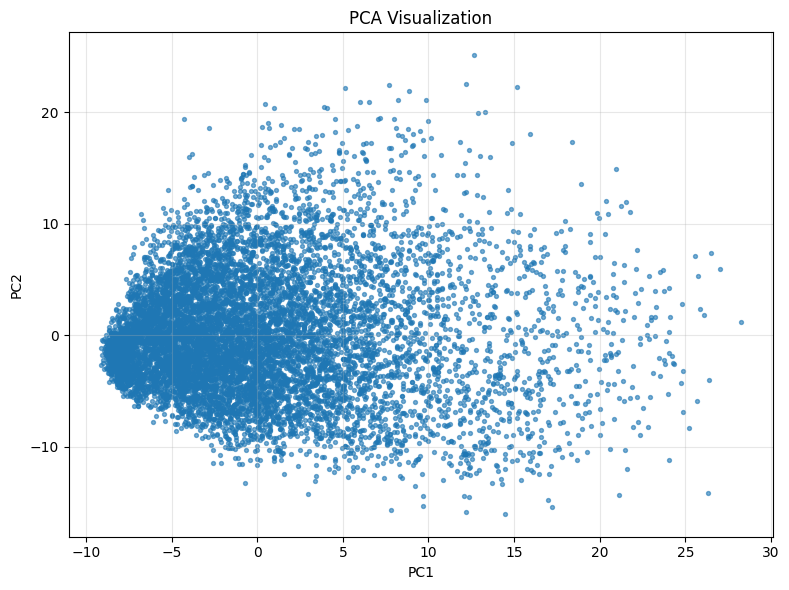

In [8]:
# PC1とPC2の散布図を描きます。
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=8, alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. 寄与率と累積寄与率を確認する

寄与率は、それぞれの主成分が元データの情報をどれくらい説明しているかを表します。

累積寄与率は、PC1から順番に足していったときに、どれくらいの情報を説明できるかを表します。

たとえばPC10までの累積寄与率が0.55なら、最初の10個の主成分で元データのばらつきの約55%を説明している、という意味です。PCAの2次元散布図を見るときは、PC1とPC2の寄与率がどの程度かも確認すると、2次元表示が全体の情報をどれくらい反映しているかを判断しやすくなります。


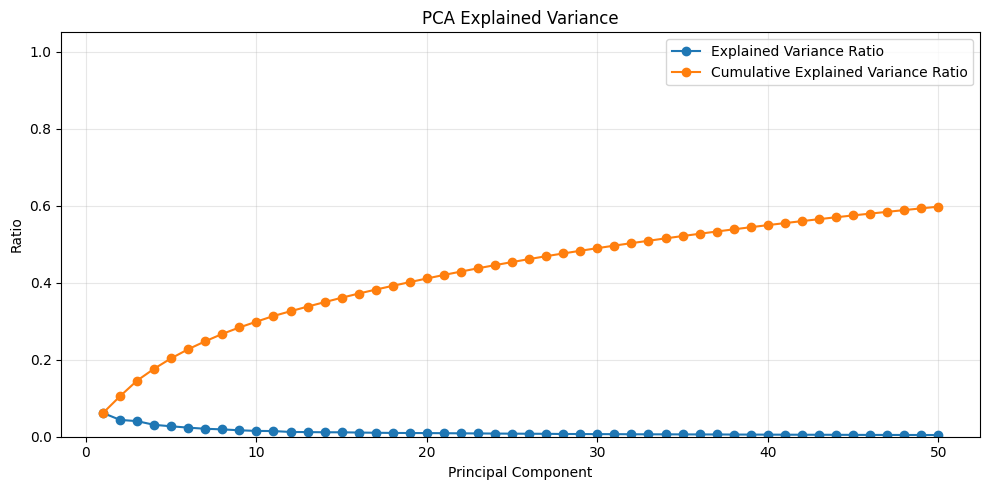

,PC,寄与率,累積寄与率
0,1,0.061640,0.061640
1,2,0.043662,0.105302
2,3,0.040458,0.145760
3,4,0.030869,0.176629
4,5,0.027049,0.203678
5,6,0.023591,0.227269
6,7,0.020660,0.247929
7,8,0.019060,0.266989
8,9,0.016714,0.283703
9,10,0.015074,0.298777


In [9]:
# 寄与率を取り出します。
explained_variance_ratio = pca.explained_variance_ratio_

# 累積寄与率を計算します。
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# 主成分番号を作ります。
component_numbers = np.arange(1, n_components + 1)

# 寄与率と累積寄与率を同じグラフに描きます。
plt.figure(figsize=(10, 5))
plt.plot(component_numbers, explained_variance_ratio, marker="o", label="Explained Variance Ratio")
plt.plot(component_numbers, cumulative_variance_ratio, marker="o", label="Cumulative Explained Variance Ratio")
plt.xlabel("Principal Component")
plt.ylabel("Ratio")
plt.title("PCA Explained Variance")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 表でも確認します。
variance_df = pd.DataFrame({
    "PC": component_numbers,
    "寄与率": explained_variance_ratio,
    "累積寄与率": cumulative_variance_ratio
})
variance_df.head(10)

## 10. PC1からPC10の10x10プロットを作る

PC1からPC10までの組み合わせを、散布図の行列として確認します。

点が多いと重くなるため、ここでは最大2000点を使って表示します。

対角線上の図は各主成分スコアの分布を表し、対角線以外の図は2つの主成分の関係を表します。PC1とPC2だけでは見えにくいまとまりが、PC3以降との組み合わせで見えることがあります。多次元データでは、1つの散布図だけで判断せず、複数の主成分の関係を比べることが重要です。


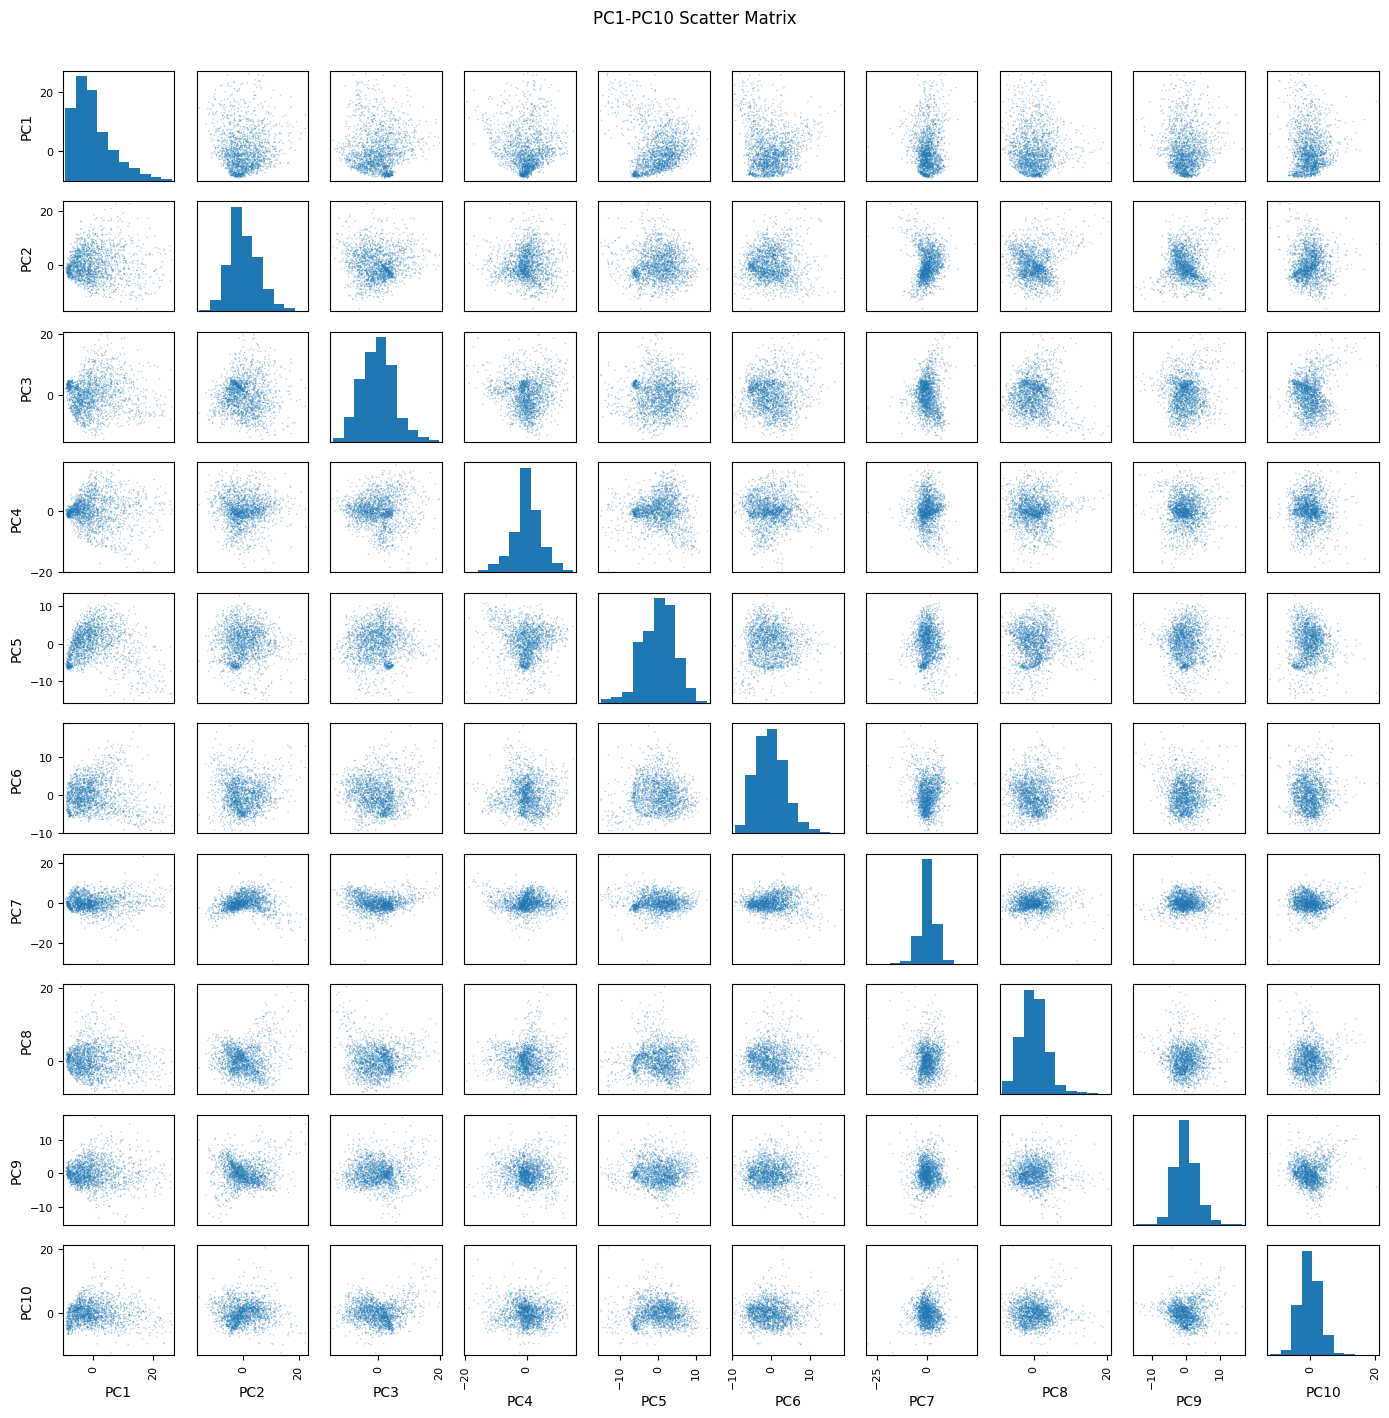

In [10]:
# 10x10プロットで使う主成分の数を指定します。
n_pair_components = 10

# 表示に使う最大データ数を指定します。
pair_plot_size = min(2000, X_pca.shape[0])

# 再現できるように乱数を固定して、表示用の行を選びます。
rng = np.random.default_rng(42)
pair_indices = rng.choice(X_pca.shape[0], size=pair_plot_size, replace=False)

# PC1からPC10までを表にします。
pc_columns = [f"PC{i}" for i in range(1, n_pair_components + 1)]
pc_df = pd.DataFrame(X_pca[pair_indices, :n_pair_components], columns=pc_columns)

# 10x10の散布図行列を描きます。
axes = pd.plotting.scatter_matrix(
    pc_df,
    figsize=(14, 14),
    diagonal="hist",
    s=4,
    alpha=0.4
)

plt.suptitle("PC1-PC10 Scatter Matrix", y=1.01)
plt.tight_layout()
plt.show()

## 11. PCAローディングを画像として確認する

PCAローディングを見ると、それぞれの主成分が画像のどの場所を強く見ているかを確認できます。

**ローディング**とは、各変数が主成分にどれくらい関係しているかを表す値です。今回の変数は各ピクセルなので、ローディングを28x28に戻すと、主成分が画像のどの領域を重視しているかを画像として確認できます。

赤と青はローディングの符号の違いを表します。絶対値が大きい場所ほど、その主成分に強く関係するピクセルです。ただし、主成分は元のピクセルを組み合わせて作った軸なので、「PC1は特定の数字そのものを表す」と単純に解釈しないようにします。


/var/folders/f0/n07b6_997s969kfj2djm5vz80000gr/T/ipykernel_52941/1137093349.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


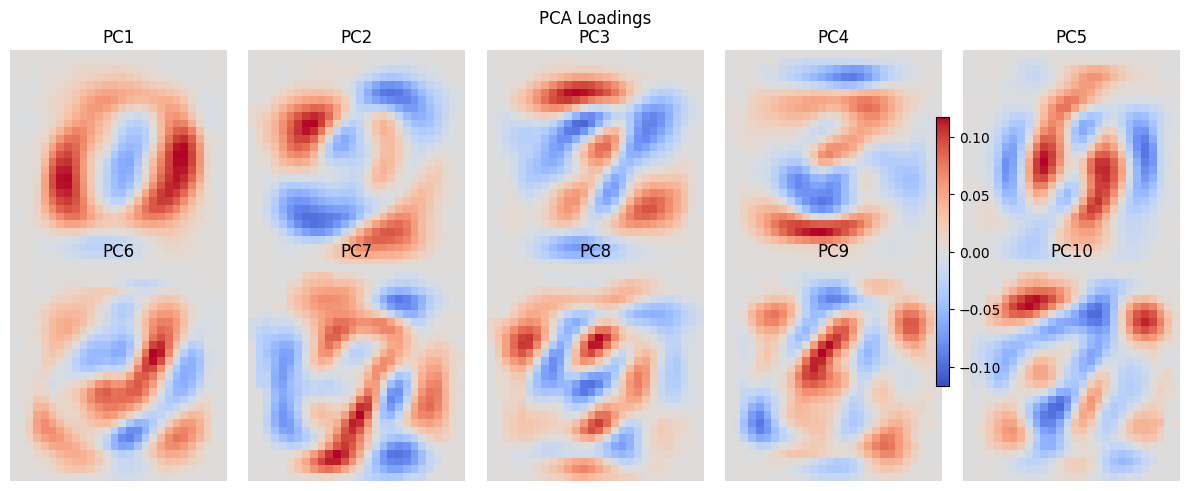

In [11]:
# PC1からPC10までのローディングを画像として表示します。
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i, ax in enumerate(axes):
    loading_image = pca.components_[i].reshape(28, 28)
    vmax = np.abs(loading_image).max()
    im = ax.imshow(loading_image, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set_title(f"PC{i + 1}")
    ax.axis("off")

fig.colorbar(im, ax=axes, shrink=0.7)
plt.suptitle("PCA Loadings")
plt.tight_layout()
plt.show()

## 12. UMAPで2次元に可視化する

UMAPは、高次元データの近さをなるべく保ったまま2次元に変換する可視化手法です。

PCAが「分散が大きい方向」を探すのに対して、UMAPは「近所関係」を重視します。ここでいう**近傍**とは、あるサンプルの近くにある別のサンプルのことです。似ている画像同士が小さな島のようにまとまるかを見たいときに使います。

主なパラメータの意味は次の通りです。

- `n_components=2`: 2次元に圧縮します。
- `n_neighbors=15`: 近傍をどれくらい広く見るかを決めます。小さいと細かい局所構造、大きいと全体構造を見やすくなります。
- `min_dist=0.1`: 2次元上で点同士をどれくらい近づけるかを決めます。小さいほどクラスターがまとまりやすくなります。
- `metric="euclidean"`: 距離の測り方としてユークリッド距離を使います。

UMAP1やUMAP2の軸そのものには、PC1のような明確な「分散が最大の方向」という意味はありません。軸の数値よりも、点のまとまりや離れ方を見ることが大切です。

この環境に `umap-learn` が入っていない場合は、下のセルで案内が表示されます。その場合は、ターミナルで `uv add umap-learn` を実行してから、もう一度ノートブックを開き直してください。


/Users/k-teppei/MI Lab/Python Seminar/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/k-teppei/MI Lab/Python Seminar/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


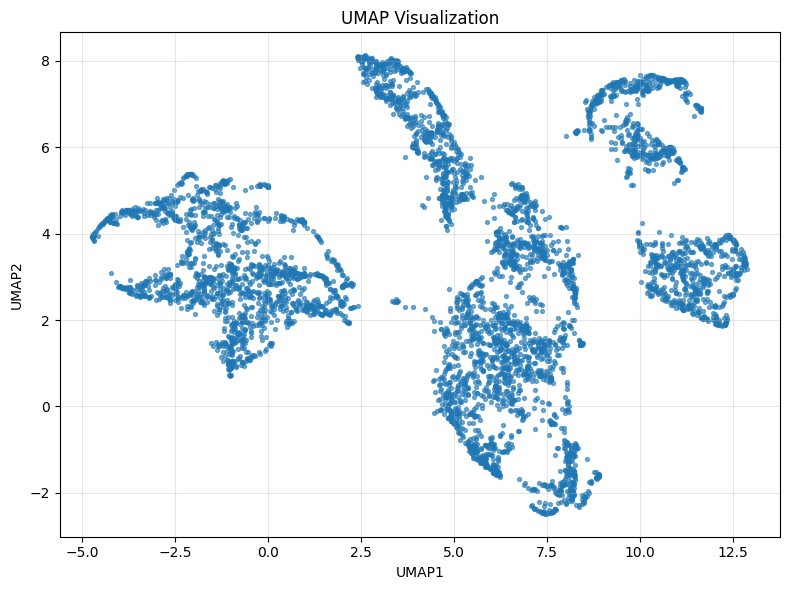

In [12]:
# UMAPが使えるか確認します。
try:
    import umap.umap_ as umap
    umap_available = True
except ModuleNotFoundError:
    umap_available = False
    print("umap-learn がインストールされていません。")
    print("ターミナルで uv add umap-learn を実行すると、このセルでUMAPを使えるようになります。")

# UMAPは計算に時間がかかるため、最大5000点で実行します。
umap_size = min(5000, X_scaled.shape[0])
umap_indices = rng.choice(X_scaled.shape[0], size=umap_size, replace=False)

if umap_available:
    # UMAPモデルを作ります。
    umap_model = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric="euclidean",
        random_state=42
    )

    # UMAPで2次元に変換します。
    X_umap = umap_model.fit_transform(X_scaled[umap_indices])

    # UMAPの散布図を描きます。
    plt.figure(figsize=(8, 6))
    plt.scatter(X_umap[:, 0], X_umap[:, 1], s=8, alpha=0.6)
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title("UMAP Visualization")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    X_umap = None

## 13. UMAPが使えない場合の代替: t-SNE

UMAPをインストールできない場合でも、似た目的の可視化手法としてt-SNEを試せます。

PowerPointの課題としてはUMAPが指定されていますが、環境確認用の代替可視化として置いています。

t-SNEも高次元データの近傍関係を2次元に写すための手法です。UMAPと同じく、点のまとまりを見る可視化には便利ですが、軸の値そのものを直接解釈する手法ではありません。計算に時間がかかりやすいため、このセルでは最大2000点に絞って実行します。


In [13]:
# UMAPが使えない場合だけ、t-SNEで2次元に可視化します。
if X_umap is None:
    # t-SNEは計算に時間がかかるため、最大2000点で実行します。
    tsne_size = min(2000, X_scaled.shape[0])
    tsne_indices = rng.choice(X_scaled.shape[0], size=tsne_size, replace=False)

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=42
    )

    X_tsne = tsne.fit_transform(X_scaled[tsne_indices])

    plt.figure(figsize=(8, 6))
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=8, alpha=0.6)
    plt.xlabel("t-SNE1")
    plt.ylabel("t-SNE2")
    plt.title("t-SNE Visualization")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 14. 階層的クラスタリングを行う

階層的クラスタリングでは、データ同士の距離をもとに、近いデータから順番にまとめていきます。

**クラスタリング**とは、似ているデータ同士をグループに分けることです。このグループを**クラスター**と呼びます。正解ラベルを使わずに、データの特徴だけからグループを作るため、教師なし学習の一種です。

ここでは、ユークリッド距離とウォード法を使います。ユークリッド距離は普通の直線距離で、ウォード法はクラスターを結合したときにクラスター内のばらつきができるだけ増えない組み合わせを選ぶ方法です。

デンドログラムは全データで描くと見づらく重いため、最大200点に絞って表示します。また、計算を軽くするためにPCAの最初の20成分を使います。これは、元の784次元をそのまま使うよりもノイズや計算量を減らし、主要な情報を使って距離を計算するためです。


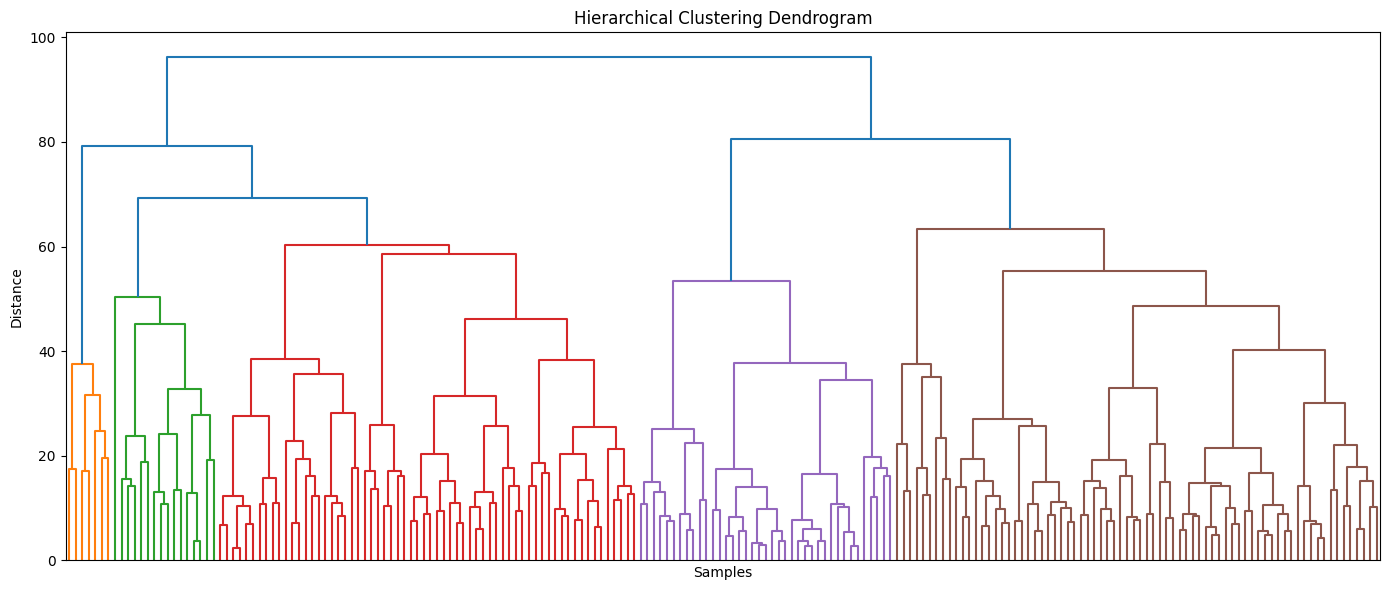

In [14]:
# デンドログラム用のデータ数を指定します。
dendrogram_size = min(200, X_pca.shape[0])
dendrogram_indices = rng.choice(X_pca.shape[0], size=dendrogram_size, replace=False)

# 計算を軽くするため、PCAの最初の20成分を使います。
X_for_hierarchical = X_pca[dendrogram_indices, :20]

# ウォード法で階層的クラスタリングを行います。
linked = linkage(X_for_hierarchical, method="ward", metric="euclidean")

# デンドログラムを描きます。
plt.figure(figsize=(14, 6))
dendrogram(linked, no_labels=True, color_threshold=None)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

## 15. 階層的クラスタリングの結果をPCAに重ねる

手書き数字は0から9までの10種類を想定できるため、ここではクラスタ数を10にします。

正解ラベルは入っていないので、クラスタ番号で色分けします。

この図では、点の位置はPCAのPC1とPC2で決まり、色だけが階層的クラスタリングのクラスター番号になります。同じ色の点が近くに集まっていれば、階層的クラスタリングで似ていると判断されたサンプルが、PCAの見え方でもまとまっていると考えられます。色が混ざっている場合は、クラスターの境界がはっきりしていない可能性があります。


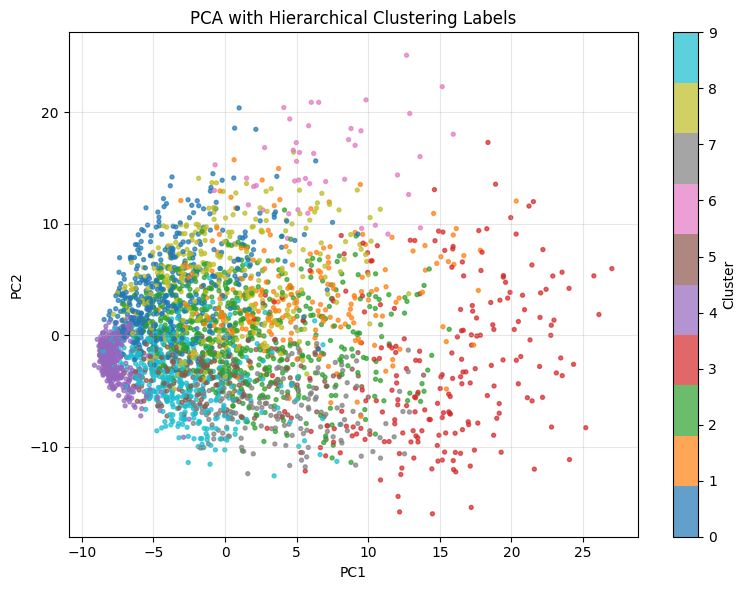

In [15]:
# クラスタ数を指定します。
n_clusters = 10

# 階層的クラスタリングは計算が重いため、最大3000点で実行します。
hierarchical_size = min(3000, X_pca.shape[0])
hierarchical_indices = rng.choice(X_pca.shape[0], size=hierarchical_size, replace=False)

# PCAの最初の20成分を使ってクラスタリングします。
X_hierarchical = X_pca[hierarchical_indices, :20]

# 階層的クラスタリングモデルを作ります。
hierarchical_model = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric="euclidean",
    linkage="ward"
)

# クラスタ番号を予測します。
hierarchical_labels = hierarchical_model.fit_predict(X_hierarchical)

# PCAの図に階層的クラスタリング結果を重ねます。
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[hierarchical_indices, 0],
    X_pca[hierarchical_indices, 1],
    c=hierarchical_labels,
    cmap="tab10",
    s=8,
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA with Hierarchical Clustering Labels")
plt.colorbar(scatter, label="Cluster")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 16. k-meansで非階層的クラスタリングを行う

k-meansは、最初にクラスタ数を決めて、各データを近いクラスタ中心に割り当てる方法です。

**非階層的クラスタリング**とは、デンドログラムのような木構造を作らず、最終的なグループ分けを直接求める方法です。k-meansでは、クラスター中心を置き、各点を最も近い中心に割り当て、中心を更新する処理を繰り返します。

階層的クラスタリングと同じく、クラスタ数を10にして実行します。入力にはPCAの最初の20成分を使います。元の784次元を直接使うより計算が軽くなり、主要なばらつきを反映した空間でクラスタリングできます。

k-meansはサンプル数が多くても比較的速く実行できますが、クラスター数を先に決める必要があります。また、初期値によって結果が変わることがあるため、`random_state` と `n_init` を指定して再現性と安定性を高めています。


In [16]:
# k-meansモデルを作ります。
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

# PCAの最初の20成分を使ってクラスタリングします。
X_for_kmeans = X_pca[:, :20]

# k-meansでクラスタ番号を予測します。
kmeans_labels = kmeans.fit_predict(X_for_kmeans)

# クラスタごとのデータ数を確認します。
kmeans_cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()
kmeans_cluster_counts

0    1051
1     986
2    2021
3     624
4     934
5     657
6     401
7    1411
8    1391
9     524
Name: count, dtype: int64

## 17. k-meansの結果をPCAに重ねる

k-meansで得られたクラスタ番号を、PCAの2次元散布図に色として表示します。

点の位置はPCAのPC1とPC2で決まり、色はk-meansのクラスター番号です。同じ色の点が近くにまとまっていれば、k-meansが似た画像を同じグループに分けられていると考えられます。色が混ざっている領域は、画像の特徴が連続的に変化していたり、クラスター境界があいまいだったりする可能性があります。

クラスター番号は機械的に付けられた番号なので、Cluster 0が数字0を意味するわけではありません。


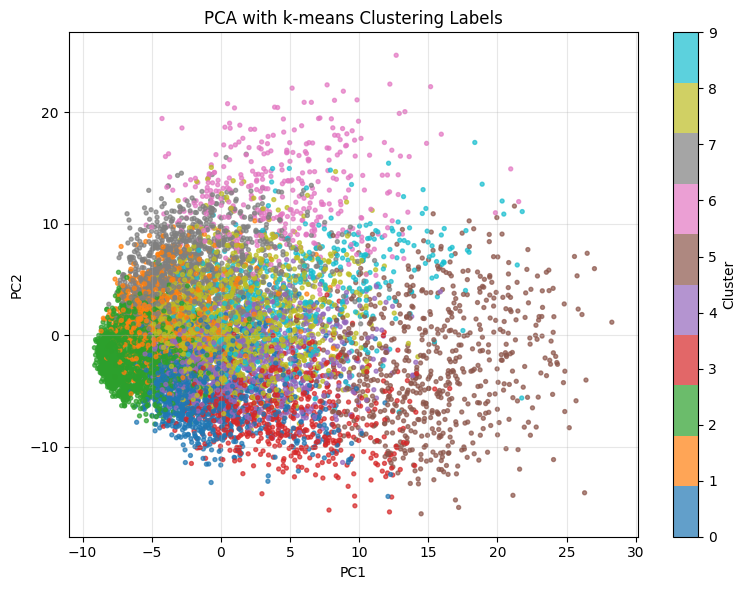

In [17]:
# PCAの図にk-meansのクラスタリング結果を重ねます。
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap="tab10",
    s=8,
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA with k-means Clustering Labels")
plt.colorbar(scatter, label="Cluster")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 18. k-meansクラスタごとの代表画像を確認する

クラスタごとに、クラスタ中心に近い画像を1枚ずつ表示します。

これにより、それぞれのクラスタがどのような数字画像を集めているかを確認できます。

`kmeans.transform()` は、各データ点から各クラスター中心までの距離を計算します。各クラスターについて、そのクラスター中心に最も近いサンプルを代表画像として選びます。代表画像を見ると、色だけでは分かりにくいクラスターの中身を直感的に確認できます。

ただし、代表画像はクラスター全体の平均像ではなく、中心に近い実在の1サンプルです。クラスター内に複数の種類の画像が混ざっている場合、代表画像だけでは全体を説明しきれないことがあります。


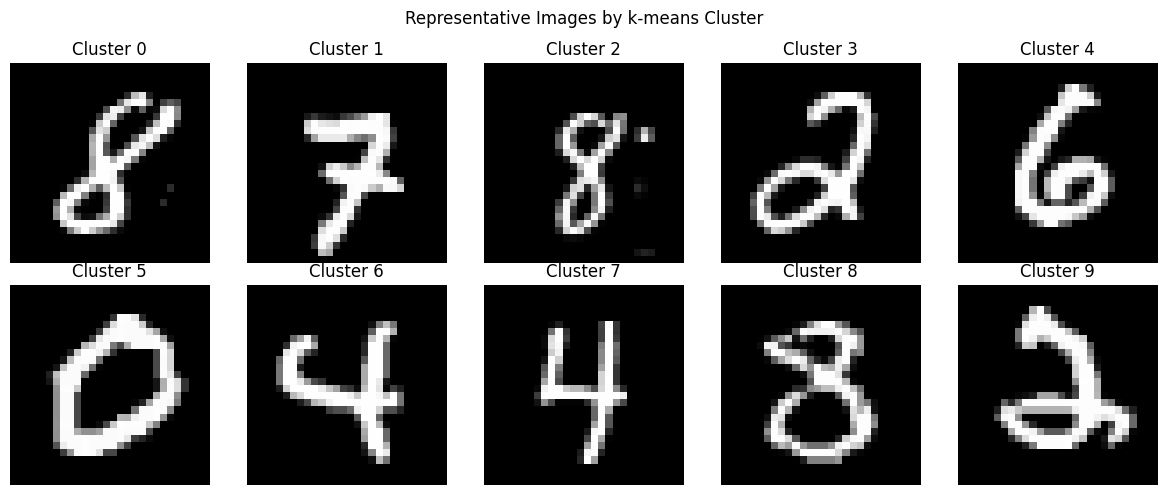

In [18]:
# 各データとクラスタ中心との距離を計算します。
distances = kmeans.transform(X_for_kmeans)

# 各クラスタについて、中心に最も近い画像の番号を探します。
representative_indices = []
for cluster_id in range(n_clusters):
    cluster_member_indices = np.where(kmeans_labels == cluster_id)[0]
    cluster_distances = distances[cluster_member_indices, cluster_id]
    representative_index = cluster_member_indices[np.argmin(cluster_distances)]
    representative_indices.append(representative_index)

# 代表画像を表示します。
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for cluster_id, ax in enumerate(axes):
    idx = representative_indices[cluster_id]
    image = X.iloc[idx].to_numpy().reshape(28, 28)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Cluster {cluster_id}")
    ax.axis("off")

plt.suptitle("Representative Images by k-means Cluster")
plt.tight_layout()
plt.show()

## 19. クラスタリング結果を数値で確認する

教師なし学習では正解ラベルがないため、分類のAccuracyのような評価はできません。

ここでは、クラスタのまとまり具合を表すシルエット係数を確認します。

シルエット係数は、1に近いほどクラスタがよく分かれていると考えられます。0に近い場合はクラスター同士の境界があいまいで、負の値になる場合は別のクラスターに入った方が自然な点が多い可能性があります。

計算量を抑えるため、このセルでは最大3000点を抽出してシルエット係数を計算します。値はクラスタリングの良し悪しを考えるための参考指標であり、画像として自然に見えるかどうかは、代表画像や散布図と合わせて確認します。


In [19]:
# シルエット係数は計算が重いため、最大3000点で計算します。
silhouette_size = min(3000, X_for_kmeans.shape[0])
silhouette_indices = rng.choice(X_for_kmeans.shape[0], size=silhouette_size, replace=False)

# k-meansのシルエット係数を計算します。
kmeans_silhouette = silhouette_score(
    X_for_kmeans[silhouette_indices],
    kmeans_labels[silhouette_indices]
)

print("k-meansのシルエット係数:", round(kmeans_silhouette, 4))

k-meansのシルエット係数: 0.1369


## 20. 教師あり学習と教師なし学習の違い

教師あり学習は、正解ラベルを使って予測モデルを作る方法です。

例として、画像とその数字ラベルがある場合に「この画像は0から9のどれか」を予測する分類があります。

教師なし学習は、正解ラベルを使わずにデータの構造を見つける方法です。

今回行ったPCA、UMAP、階層的クラスタリング、k-meansは教師なし学習です。正解ラベルを使わず、画像同士の似ている・似ていないという関係から、データを見やすくしたりグループ分けしたりします。

今回のように正解ラベルがない場合、クラスタリング結果を「正解・不正解」で評価するのではなく、散布図のまとまり、代表画像、シルエット係数などを組み合わせて、データの構造を解釈します。


## 21. まとめ

このノートブックでは、手書き数字画像を784個のピクセル値として扱い、PCAとUMAPで2次元に可視化しました。

PCAでは寄与率、累積寄与率、PC1からPC10までの関係、ローディングも確認しました。

さらに、階層的クラスタリングとk-meansを行い、クラスタリング結果をPCAの図に重ねて表示しました。

**用語まとめ**

| 用語 | 意味 |
|---|---|
| サンプル | 解析対象の1つ1つのデータです。このノートブックでは1枚の画像が1サンプルです。 |
| 変数 | サンプルを説明する列です。ここでは各ピクセル値が変数です。 |
| 次元 | 1つのサンプルを何個の数値で表すかという数です。784ピクセルなら784次元です。 |
| 標準化 | 平均を0、標準偏差を1にそろえる処理です。 |
| 主成分 | PCAで作られる新しい軸です。PC1、PC2のように呼びます。 |
| スコア | 各サンプルが主成分軸上でどの位置にあるかを表す座標です。 |
| ローディング | 各変数が主成分にどれくらい関係しているかを表す値です。 |
| 寄与率 | ある主成分が全体の情報の何割を説明しているかを表します。 |
| 累積寄与率 | PC1から順に寄与率を足した値です。 |
| 近傍 | あるサンプルの近くにあるサンプルのことです。UMAPでは近傍関係を重視します。 |
| クラスター | 似ているサンプルをまとめたグループです。 |
| クラスタリング | 正解ラベルを使わずに、似ているデータ同士をグループ分けする方法です。 |
| 階層的クラスタリング | データを少しずつ結合して、木構造としてグループを作る方法です。 |
| デンドログラム | 階層的クラスタリングの結合過程を表す木の図です。 |
| Ward法 | クラスター内のばらつきが増えにくい組み合わせから結合する方法です。 |
| 非階層的クラスタリング | 木構造を作らず、最終的なグループ分けを直接求める方法です。 |
| k-means | クラスター中心と各点の距離が小さくなるように、データをK個に分ける方法です。 |
| シルエット係数 | クラスターのまとまり具合を表す指標です。1に近いほどよく分かれていると考えます。 |


In [20]:
# 最後に、主な結果をまとめて表示します。
summary_df = pd.DataFrame({
    "項目": [
        "読み込んだデータ数",
        "ピクセル特徴量数",
        "PCAで作った主成分数",
        "PC1-PC10の累積寄与率",
        "k-meansのクラスタ数",
        "k-meansのシルエット係数"
    ],
    "値": [
        X.shape[0],
        X.shape[1],
        n_components,
        round(cumulative_variance_ratio[9], 4),
        n_clusters,
        round(kmeans_silhouette, 4)
    ]
})

summary_df

,項目,値
0,読み込んだデータ数,10000.0000
1,ピクセル特徴量数,784.0000
2,PCAで作った主成分数,50.0000
3,PC1-PC10の累積寄与率,0.2988
4,k-meansのクラスタ数,10.0000
5,k-meansのシルエット係数,0.1369
